In [ ]:
# Import necessary libraries

import pandas as pd
import numpy as np
import seaborn as sns
sns.set(color_codes=True)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.tree import plot_tree
from imblearn.over_sampling import SMOTE


from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load the dataset

df = pd.read_excel('ML_3673_Cancer_Data_Set.xlsx')



## 1. Data Understanding and Exploration

In [ ]:
# Display the first few rows of the dataset

df.head()

,Survived,Class,Sex,Age,Bed Cost(£),Hospital,Unnamed: 6,Unnamed: 7
0,0,Gen Population,male,22.0,7.2500,S,NaN,S = Sussex
1,1,Premium,female,38.0,71.2833,C,NaN,C = Devon
2,1,Gen Population,female,26.0,7.9250,S,NaN,Q = Bristol
3,1,Premium,female,35.0,53.1000,S,NaN,NaN
4,0,Gen Population,male,35.0,8.0500,S,NaN,0 = Survived


In [ ]:
# Get information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     599 non-null    int64  
 1   Class        599 non-null    object 
 2   Sex          599 non-null    object 
 3   Age          478 non-null    float64
 4   Bed Cost(£)  599 non-null    float64
 5   Hospital     598 non-null    object 
 6   Unnamed: 6   0 non-null      float64
 7   Unnamed: 7   5 non-null      object 
dtypes: float64(3), int64(1), object(4)
memory usage: 37.6+ KB


In [ ]:
# Data types of each column in the DataFrame
df.dtypes

,0
Survived,int64
Class,object
Sex,object
Age,float64
Bed Cost(£),float64
Hospital,object
Unnamed: 6,float64
Unnamed: 7,object


In [ ]:
# Display column names of the DataFrame
df.columns

Index(['Survived', 'Class', 'Sex', 'Age', 'Bed Cost(£)', 'Hospital',
       'Unnamed: 6', 'Unnamed: 7'],
      dtype='object')

In [ ]:
# Get the number of rows and columns in the DataFrame
df.shape

(599, 8)

In [ ]:
# Count non-NA cells for each column
df.count()

,0
Survived,599
Class,599
Sex,599
Age,478
Bed Cost(£),599
Hospital,598
Unnamed: 6,0
Unnamed: 7,5


In [ ]:
for column in df.columns:
# Get the first value of the current column
    value=df[column].values[0]
# Get the data type of the first value
    type_value=type(value).__name__

    print(f"column:{column} ----> first value: {value} ----> Data Type:{type(value)}")

column:Survived ----> first value: 0 ----> Data Type:<class 'numpy.int64'>
column:Class ----> first value: Gen Population ----> Data Type:<class 'str'>
column:Sex ----> first value: male ----> Data Type:<class 'str'>
column:Age ----> first value: 22.0 ----> Data Type:<class 'numpy.float64'>
column:Bed Cost(£) ----> first value: 7.25 ----> Data Type:<class 'numpy.float64'>
column:Hospital ----> first value: S ----> Data Type:<class 'str'>
column:Unnamed: 6 ----> first value: nan ----> Data Type:<class 'numpy.float64'>
column:Unnamed: 7 ----> first value: S = Sussex ----> Data Type:<class 'str'>


In [ ]:
# Descriptive statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Survived,599.0,0.392321,0.488676,0.0,0.000,0.0,1.0,1.0000
Age,478.0,30.280335,14.763718,1.0,21.000,29.0,38.0,82.0000
Bed Cost(£),599.0,31.835503,46.303299,0.0,7.925,14.5,30.5,512.3292
Unnamed: 6,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 2. Data Preprocessing

In [ ]:
# Drop Unnecessary columns

df.drop(['Unnamed: 6', 'Unnamed: 7'], axis=1, inplace=True)
df.head()

,Survived,Class,Sex,Age,Bed Cost(£),Hospital
0,0,Gen Population,male,22.0,7.2500,S
1,1,Premium,female,38.0,71.2833,C
2,1,Gen Population,female,26.0,7.9250,S
3,1,Premium,female,35.0,53.1000,S
4,0,Gen Population,male,35.0,8.0500,S


In [ ]:
# transfer "Survived" column as dependent variable to the end of the dataset

survived_col = df.pop("Survived")
df["Survived"] = survived_col    # Append the column to the end of the dataframe
df.shape

(599, 6)

In [ ]:
df.head()

,Class,Sex,Age,Bed Cost(£),Hospital,Survived
0,Gen Population,male,22.0,7.2500,S,0
1,Premium,female,38.0,71.2833,C,1
2,Gen Population,female,26.0,7.9250,S,1
3,Premium,female,35.0,53.1000,S,1
4,Gen Population,male,35.0,8.0500,S,0


In [ ]:
# Check for duplicated values

df.duplicated().sum()

71

In [ ]:
# Check for missing values

df.isnull().sum()

,0
Class,0
Sex,0
Age,121
Bed Cost(£),0
Hospital,1
Survived,0


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
#shape of df after dropping duplicated rows
df.shape

(528, 6)

In [ ]:
#df rows after dropping duplicated rows
df.count()

,0
Class,528
Sex,528
Age,456
Bed Cost(£),528
Hospital,527
Survived,528


In [ ]:
# Check for missing value after dropping duplicated rows

df.isnull().sum()

,0
Class,0
Sex,0
Age,72
Bed Cost(£),0
Hospital,1
Survived,0


In [ ]:
#These lines of code print the unique values present in the specified columns of the df. In essence, these lines provide a quick way to inspect the categorical features in your dataset and understand the distinct values within each. This is a crucial step in data exploration, allowing you to identify potential issues like unexpected values or inconsistent labeling before proceeding with further analysis or model building.
print(df["Class"].unique())
print(df["Sex"].unique())
print(df["Hospital"].unique())
print(df["Survived"].unique())

['Gen Population' 'Premium' 'Side Ward']
['male' 'female']
['S' 'C' 'Q' nan]
[0 1]


In [ ]:
df["Age"].value_counts()

,count
Age,
24.0,21
22.0,20
28.0,20
19.0,18
36.0,16
...,...
66.0,1
10.0,1
13.0,1


In [ ]:
df['Age'].unique()


array([22., 38., 26., 35., 28., 54.,  2., 27., 14.,  4., 58., 20., 39.,
       55., nan, 31., 34., 15.,  8., 19., 40., 66., 42., 21., 18.,  3.,
        7., 49., 29., 65.,  5., 11., 45., 17., 32., 16., 25., 61., 30.,
       33., 23., 24., 46., 59., 71., 37., 47., 70., 12.,  9., 51., 56.,
       44.,  1., 50., 36., 62., 41., 52., 63., 82., 43., 60., 10., 64.,
       13., 48., 75., 53.])

In [ ]:
# plt.figure(figsize=(6,8))
# plt.scatter(df['Age'],df['Bed Cost(£)'])

# plt.xlabel('Age')
# plt.ylabel('Bed Cost(£)')
# plt.title('Age vs Bed Cost(£)')

# plt.grid(True)
# plt.show()


In [ ]:
# plt.figure(figsize=(6,8))
# plt.scatter(df['Bed Cost(£)'], df['Age'], c='r')

# plt.xlabel('Bed Cost(£)')
# plt.ylabel('Age')
# plt.title('Bed Cost(£) vs Age')
# plt.grid(True)
# plt.show()

In [ ]:
# Initialize LabelEncoder

le = LabelEncoder()
for col in ['Class', 'Hospital', 'Sex']:
    df[col] = le.fit_transform(df[col])


In [ ]:
# Drop rows with missing values in the 'Hospital' column, modifying the DataFrame in place.

df["Hospital"].dropna(inplace=True)

In [ ]:
df.isna().sum()

,0
Class,0
Sex,0
Age,72
Bed Cost(£),0
Hospital,0
Survived,0


In [ ]:
df


,Class,Sex,Age,Bed Cost(£),Hospital,Survived
0,0,1,22.0,7.2500,2,0
1,1,0,38.0,71.2833,0,1
2,0,0,26.0,7.9250,2,1
3,1,0,35.0,53.1000,2,1
4,0,1,35.0,8.0500,2,0
...,...,...,...,...,...,...
592,0,1,47.0,7.2500,2,0
595,0,1,36.0,24.1500,2,0
596,2,0,NaN,33.0000,2,1
597,0,1,49.0,0.0000,2,0


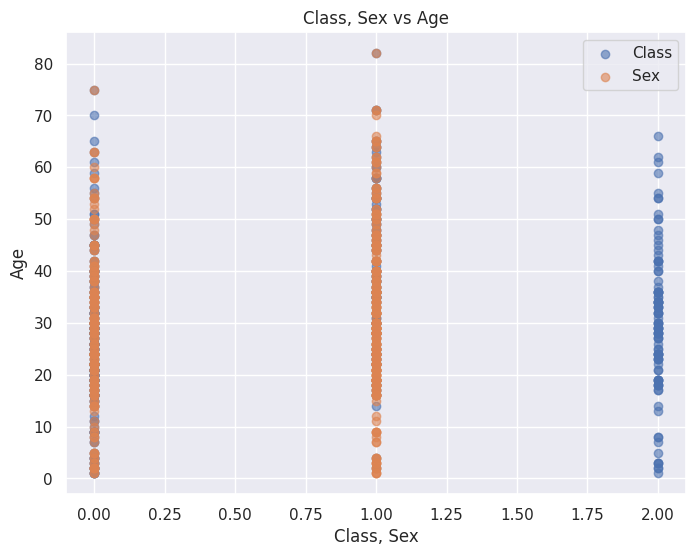

In [ ]:
# Plot the relationship between 'Class' and 'Sex' with 'Age'

col_to_plot=['Class', 'Sex']

plt.figure(figsize=(8,6))

for col in col_to_plot:
    if col in ['Class', 'Sex']:
        plt.scatter(df[col], df['Age'], label=col, alpha=0.6)
    else:
        plt.scatter(df[col], df['Age'], label=col, alpha=0.6)

plt.xlabel('Class, Sex')
plt.ylabel('Age')
plt.legend(loc='best')
plt.title('Class, Sex vs Age')
plt.grid(True)
plt.show()


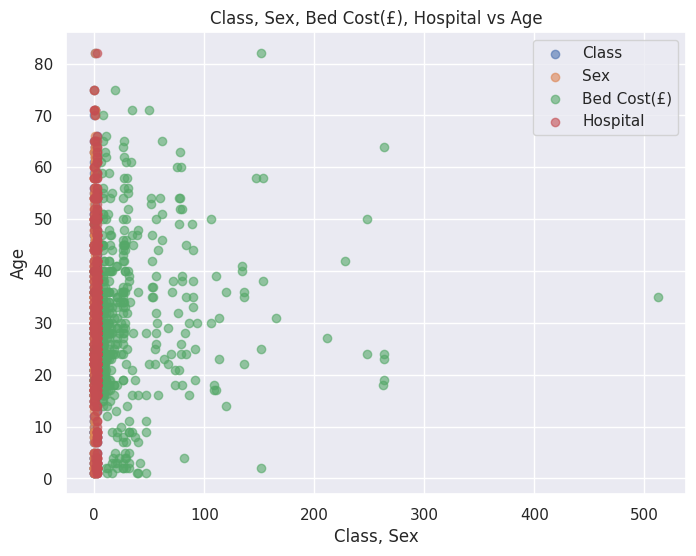

In [ ]:
# Plot the relationship between 'Class', 'Sex', 'Bed Cost(£)'and 'Hospital' with 'Age'.
col_to_plot=['Class', 'Sex', 'Bed Cost(£)', 'Hospital' ]

plt.figure(figsize=(8,6))

for col in col_to_plot:
    if col in ['Class', 'Sex']:

        plt.scatter(df[col], df['Age'], label=col, alpha=0.6)
    else:
        plt.scatter(df[col], df['Age'], label=col, alpha=0.6)

plt.xlabel('Class, Sex')
plt.ylabel('Age')
plt.legend(loc='best')
plt.title('Class, Sex, Bed Cost(£), Hospital vs Age')
plt.grid(True)
plt.show()

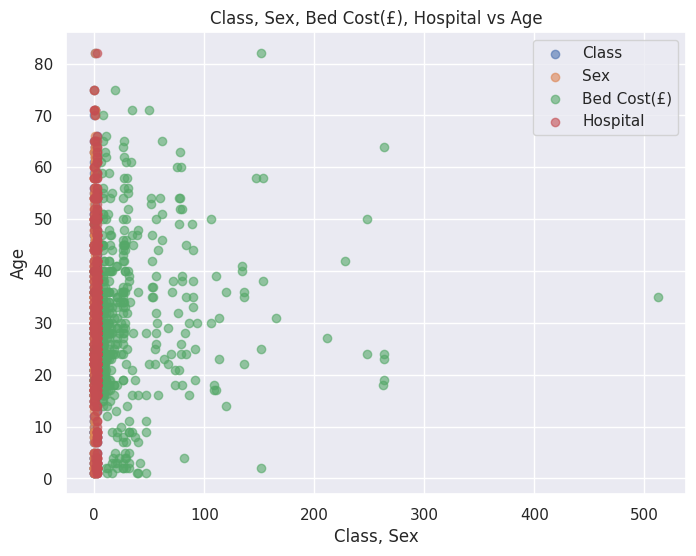

In [ ]:
col_to_plot=['Class', 'Sex', 'Bed Cost(£)', 'Hospital' ]

plt.figure(figsize=(8,6))

for col in col_to_plot:
    if col in ['Class', 'Sex','Bed Cost(£)', 'Hospital']:
    #if col in ['Class', 'Sex']:
        plt.scatter(df[col], df['Age'], label=col, alpha=0.6)
    else:
        plt.scatter(df[col], df['Age'], label=col, alpha=0.6)

plt.xlabel('Class, Sex')
plt.ylabel('Age')
plt.legend(loc='best')
plt.title('Class, Sex, Bed Cost(£), Hospital vs Age')
plt.grid(True)
plt.show()

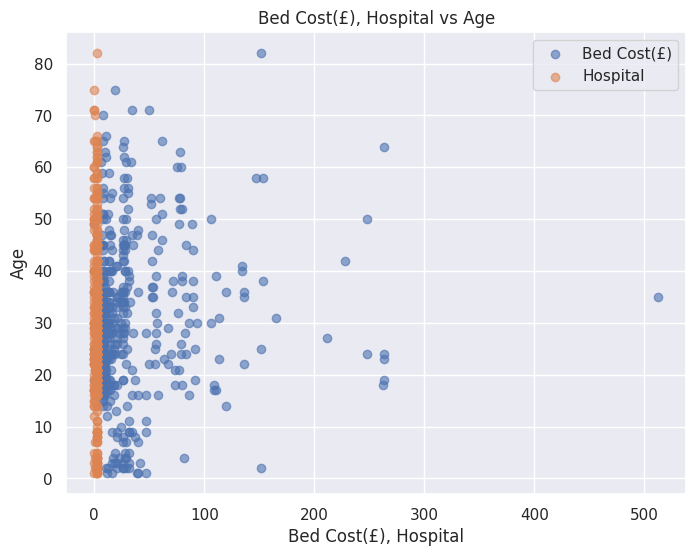

In [ ]:
# Plot the relationship between 'Bed Cost(£)'and 'Hospital' with 'Age'

col_to_plot=['Bed Cost(£)', 'Hospital' ]

plt.figure(figsize=(8,6))

for col in col_to_plot:
    if col in ['Class', 'Sex']:
    #if col in ['Class', 'Sex']:
        plt.scatter(df[col], df['Age'], label=col, alpha=0.6)
    else:
        plt.scatter(df[col], df['Age'], label=col, alpha=0.6)

plt.xlabel('Bed Cost(£), Hospital')
plt.ylabel('Age')
plt.legend(loc='best')
plt.title('Bed Cost(£), Hospital vs Age')
plt.grid(True)
plt.show()

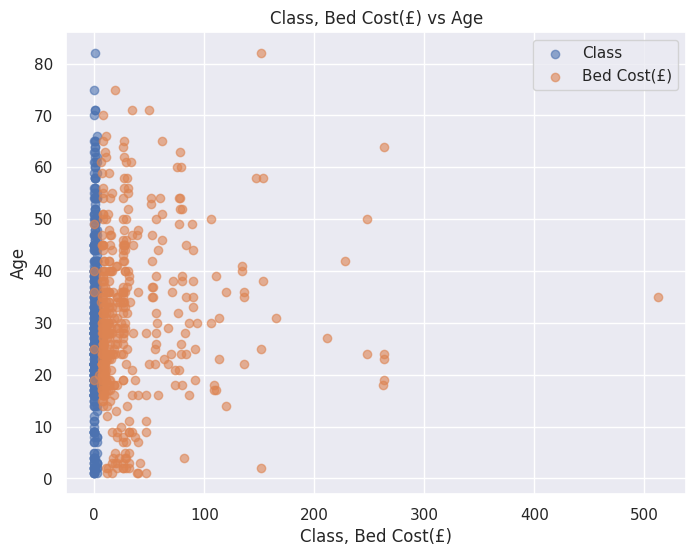

In [ ]:
# Plot the relationship between 'Class'and 'Bed Cost(£)' with 'Age'

col_to_plot=['Class', 'Bed Cost(£)' ]

plt.figure(figsize=(8,6))

for col in col_to_plot:
    if col in ['Class', 'Sex']:
    #if col in ['Class', 'Sex']:
        plt.scatter(df[col], df['Age'], label=col, alpha=0.6)
    else:
        plt.scatter(df[col], df['Age'], label=col, alpha=0.6)

plt.xlabel('Class, Bed Cost(£)')
plt.ylabel('Age')
plt.legend(loc='best')
plt.title('Class, Bed Cost(£) vs Age')
plt.grid(True)
plt.show()

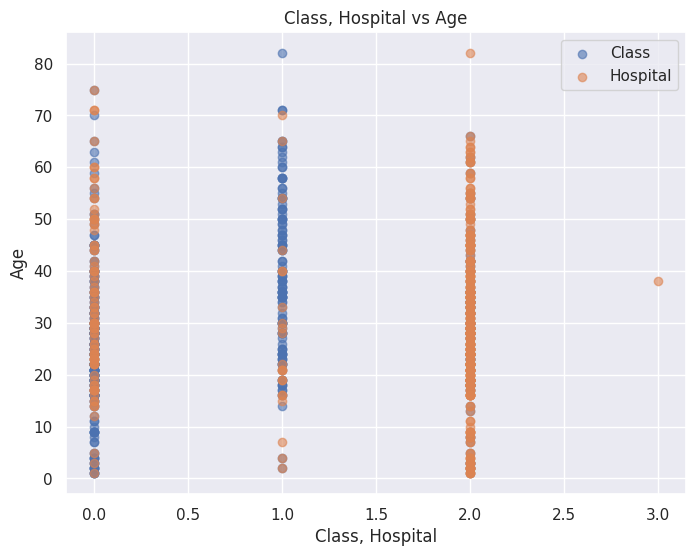

In [ ]:
# Plot the relationship between 'Class'and 'Hospital' with 'Age'

col_to_plot=['Class', 'Hospital' ]

plt.figure(figsize=(8,6))

for col in col_to_plot:
    if col in ['Class', 'Sex']:
    #if col in ['Class', 'Sex']:
        plt.scatter(df[col], df['Age'], label=col, alpha=0.6)
    else:
        plt.scatter(df[col], df['Age'], label=col, alpha=0.6)

plt.xlabel('Class, Hospital')
plt.ylabel('Age')
plt.legend(loc='best')
plt.title('Class, Hospital vs Age')
plt.grid(True)
plt.show()

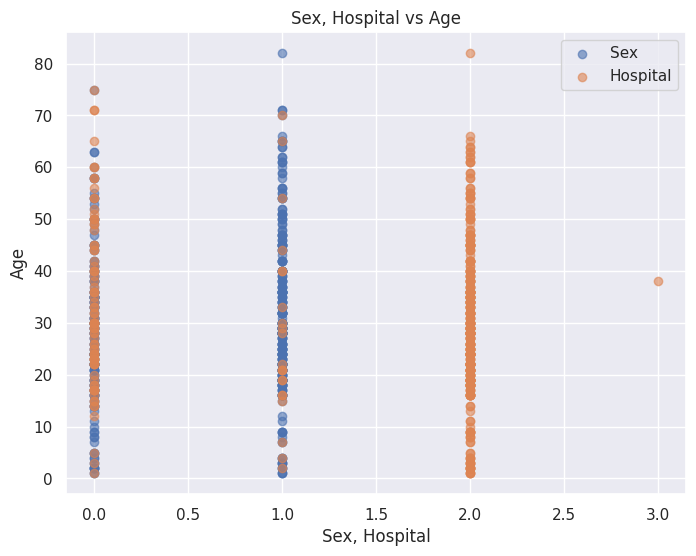

In [ ]:
# Plot the relationship between 'Sex'and 'Hospital' with 'Age'

col_to_plot=['Sex', 'Hospital' ]

plt.figure(figsize=(8,6))

for col in col_to_plot:
    if col in ['Class', 'Sex']:
    #if col in ['Class', 'Sex']:
        plt.scatter(df[col], df['Age'], label=col, alpha=0.6)
    else:
        plt.scatter(df[col], df['Age'], label=col, alpha=0.6)

plt.xlabel('Sex, Hospital')
plt.ylabel('Age')
plt.legend(loc='best')
plt.title('Sex, Hospital vs Age')
plt.grid(True)
plt.show()

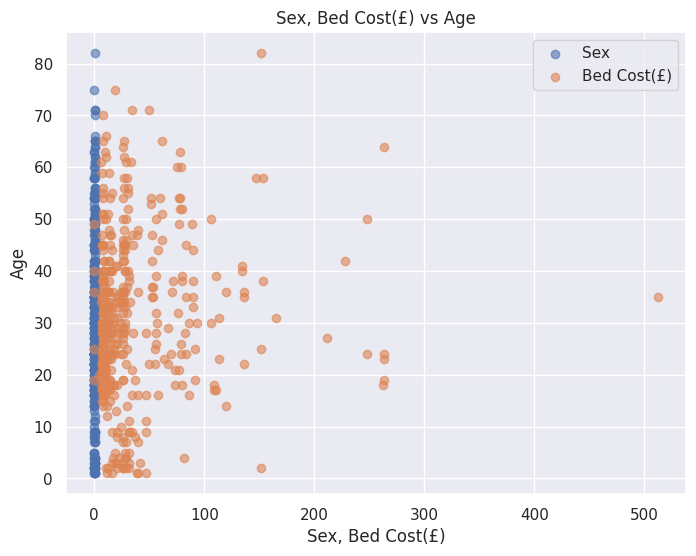

In [ ]:
# Plot the relationship between 'Sex'and 'Bed Cost(£)' with 'Age'

col_to_plot=['Sex', 'Bed Cost(£)' ]

plt.figure(figsize=(8,6))

for col in col_to_plot:
    if col in ['Class', 'Sex']:
    #if col in ['Class', 'Sex']:
        plt.scatter(df[col], df['Age'], label=col, alpha=0.6)
    else:
        plt.scatter(df[col], df['Age'], label=col, alpha=0.6)

plt.xlabel('Sex, Bed Cost(£)')
plt.ylabel('Age')
plt.legend(loc='best')
plt.title('Sex, Bed Cost(£) vs Age')
plt.grid(True)
plt.show()

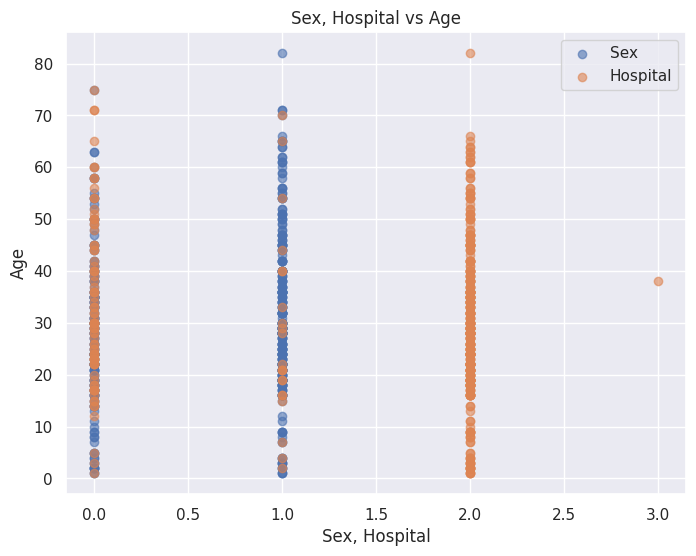

In [ ]:
# Plot the relationship between 'Sex'and 'Hospital' with 'Age'

col_to_plot=['Sex', 'Hospital' ]

plt.figure(figsize=(8,6))

for col in col_to_plot:
    if col in ['Class', 'Sex']:
    #if col in ['Class', 'Sex']:
        plt.scatter(df[col], df['Age'], label=col, alpha=0.6)
    else:
        plt.scatter(df[col], df['Age'], label=col, alpha=0.6)

plt.xlabel('Sex, Hospital')
plt.ylabel('Age')
plt.legend(loc='best')
plt.title('Sex, Hospital vs Age')
plt.grid(True)
plt.show()

In [ ]:
# Fill missing 'Age' values with the median age.  This is done in place to modify the original DataFrame.

df["Age"].fillna(df["Age"].median(),inplace = True)

In [ ]:
#to ensure no missing values remain
assert df.isnull().sum().sum() == 0, "Missing values still exist!"

In [ ]:
df.isna().sum()

,0
Class,0
Sex,0
Age,0
Bed Cost(£),0
Hospital,0
Survived,0


In [ ]:
df['Age'].value_counts()

,count
Age,
29.0,88
24.0,21
22.0,20
28.0,20
19.0,18
...,...
66.0,1
10.0,1
13.0,1


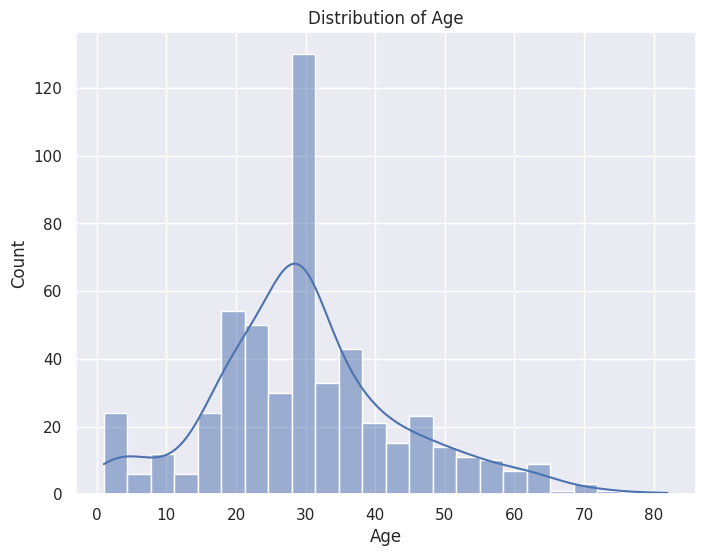

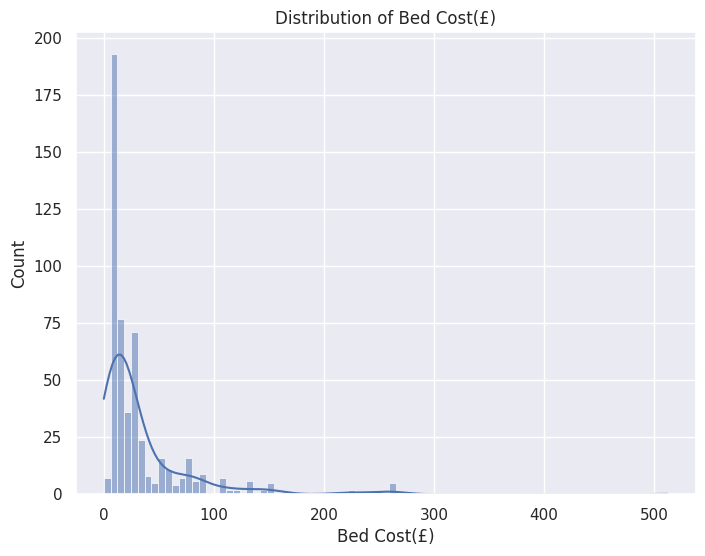

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

#Numerical features
for col in ['Age', 'Bed Cost(£)']:
   plt.figure(figsize=(8, 6))
   sns.histplot(df[col], kde=True)  # Histogram with Kernel Density Estimate
   plt.title(f'Distribution of {col}')
   plt.show()

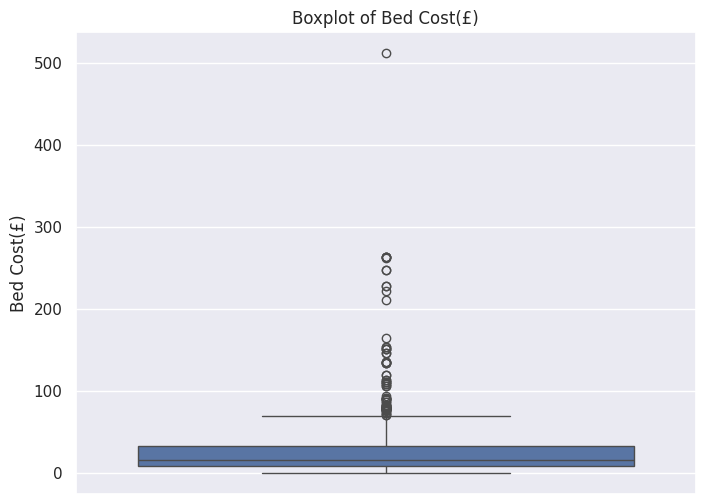

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df[col])  # Boxplot to identify outliers
plt.title(f'Boxplot of {col}')
plt.show()

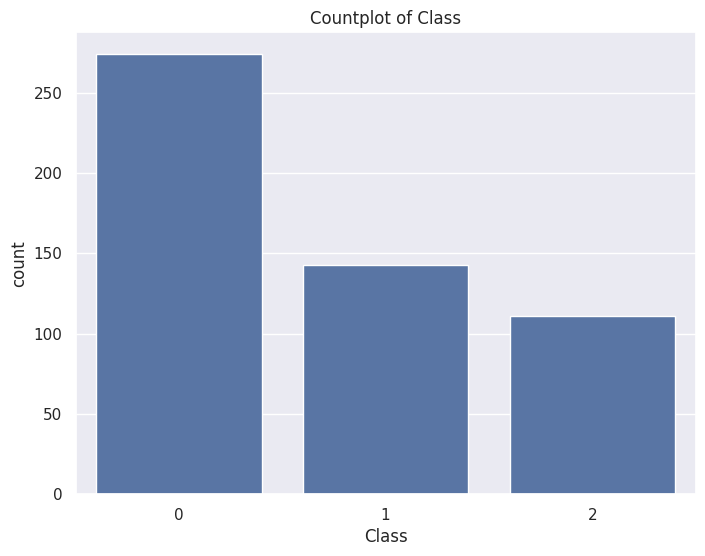

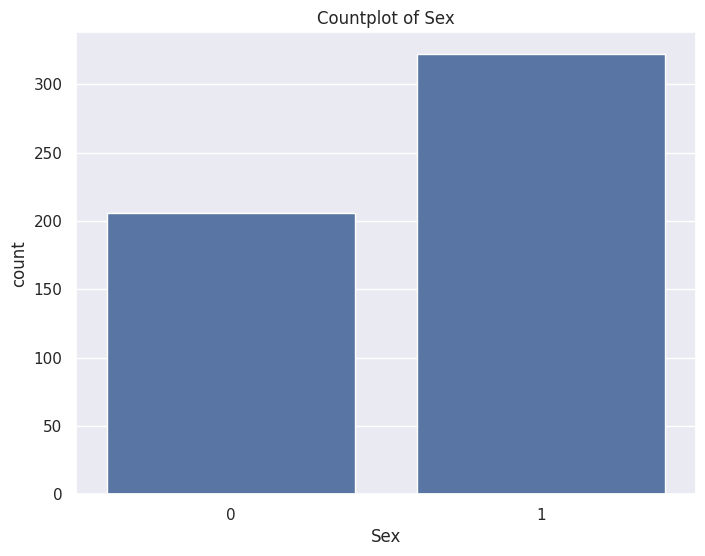

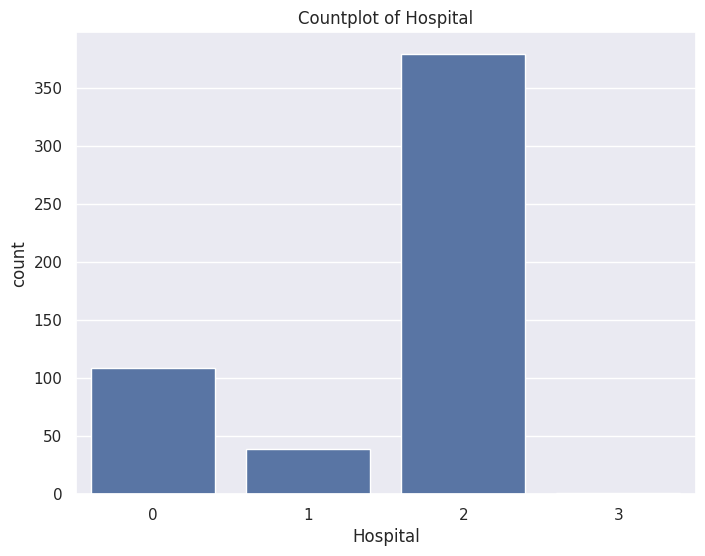

In [ ]:
# Categorical features
for col in ['Class', 'Sex', 'Hospital']:
   plt.figure(figsize=(8, 6))
   sns.countplot(x=col, data=df)
   plt.title(f'Countplot of {col}')
   plt.show()

In [ ]:
# # Correlation Matrix
# plt.figure(figsize=(10, 8))
# sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
# plt.title('Correlation Matrix')
# plt.show()

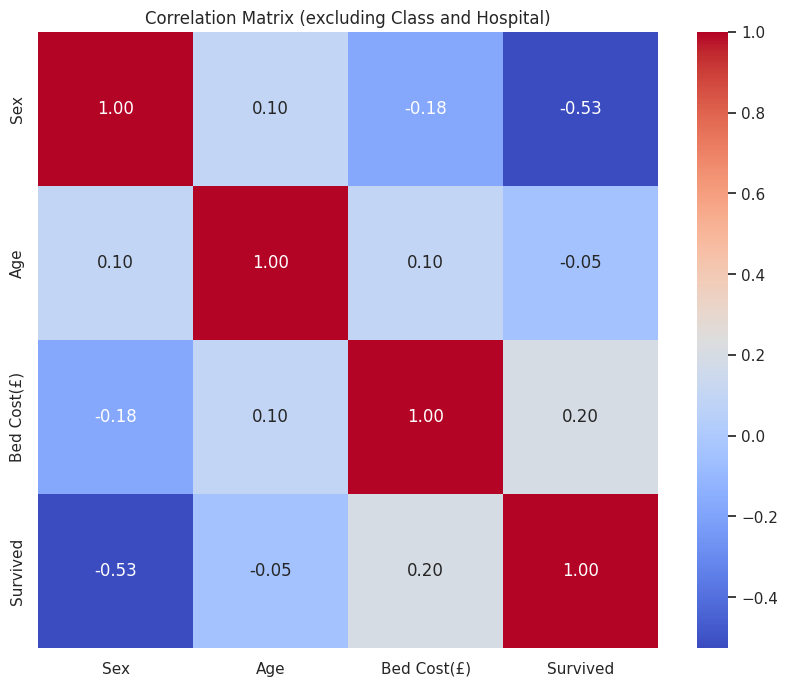

In [ ]:
# Correlation Matrix excluding 'Class' and 'Hospital'
df_corr = df.drop(['Class', 'Hospital'], axis=1)
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (excluding Class and Hospital)')
plt.show()

In [ ]:
# Correlation calculation for Class and Survived
correlation_class = df['Class'].corr(df['Survived'])
print(f"Correlation between Class and Survived: {correlation_class}")

# Correlation calculation for Hospital and Survived
correlation_hospital = df['Hospital'].corr(df['Survived'])
print(f"Correlation between Hospital and Survived: {correlation_hospital}")


Correlation between Class and Survived: 0.24219212986822053
Correlation between Hospital and Survived: -0.12626264273062832


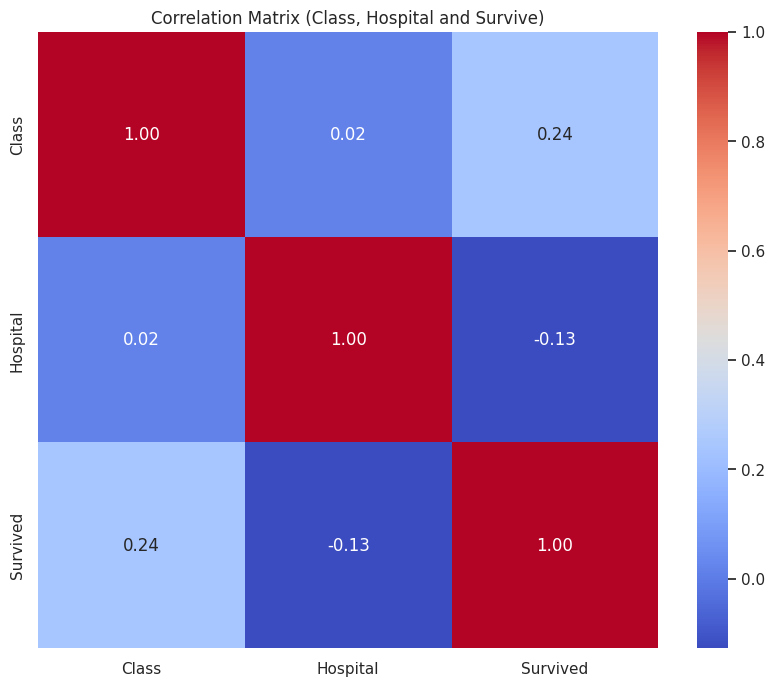

In [ ]:


df_corr = df[['Class', 'Hospital', 'Survived']]
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Class, Hospital and Survive)')
plt.show()

In [ ]:


# The p-value represents the probability of observing the obtained results (or more extreme results) if there is no real association between the two variables being compared.

# In the provided code, chi-square tests are performed to assess the relationship between:

# A small p-value (typically less than 0.05) suggests strong evidence against the null hypothesis (no association).  In this context, a small p-value would indicate a statistically significant relationship between the variables.
# A large p-value suggests weak evidence against the null hypothesis.  A large p-value would indicate that the observed relationship could be due to chance, and there's no strong evidence of a real association.


from scipy.stats import chi2_contingency

# Chi-Square test for 'Class' and 'Survived'
contingency_class = pd.crosstab(df['Class'], df['Survived'])
chi2_class, p_class, dof_class, _ = chi2_contingency(contingency_class)
print(f"Chi-Square Test for Class: p-value = {p_class}")

# Chi-Square test for 'Hospital' and 'Survived'
contingency_hospital = pd.crosstab(df['Hospital'], df['Survived'])
chi2_hospital, p_hospital, dof_hospital, _ = chi2_contingency(contingency_hospital)
print(f"Chi-Square Test for Hospital: p-value = {p_hospital}")


Chi-Square Test for Class: p-value = 1.4650085188323724e-10
Chi-Square Test for Hospital: p-value = 0.014727950929091389


In [ ]:
# prompt: what p_value shows

The p-value represents the probability of observing the obtained results (or more extreme results) if there is no real association between the two variables being compared.

In the provided code, chi-square tests are performed to assess the relationship between:

1.  **`Class` and `Survived`**:  The `p_class` value from `chi2_contingency(contingency_class)` shows the probability of observing the relationship between patient class and survival, assuming there is no actual association between them.

2.  **`Hospital` and `Survived`**: The `p_hospital` value from `chi2_contingency(contingency_hospital)` shows the probability of observing the relationship between the hospital and survival, assuming no real association.

**Interpretation:**

*   A small p-value (typically less than 0.05) suggests strong evidence against the null hypothesis (no association).  In this context, a small p-value would indicate a statistically significant relationship between the variables.
*   A large p-value suggests weak evidence against the null hypothesis.  A large p-value would indicate that the observed relationship could be due to chance, and there's no strong evidence of a real association.


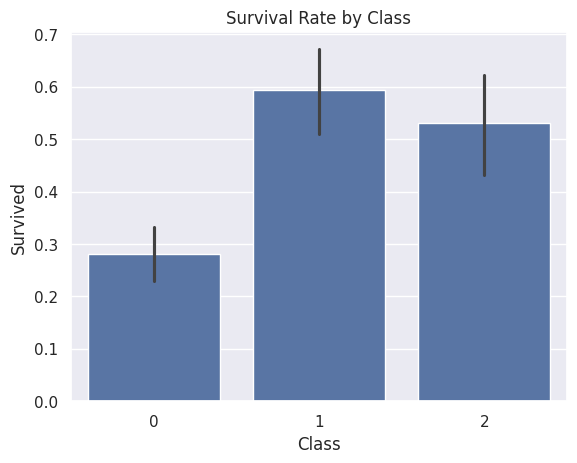

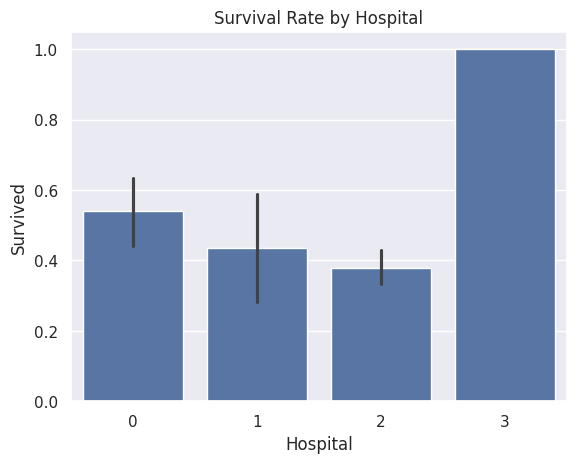

In [ ]:
#Visualizing the Results



# Survival rate by Class
sns.barplot(x='Class', y='Survived', data=df)
plt.title("Survival Rate by Class")
plt.show()

# Survival rate by Hospital
sns.barplot(x='Hospital', y='Survived', data=df)
plt.title("Survival Rate by Hospital")
plt.show()


In [ ]:
# Calculate the normalized value counts of the 'Survived' column.

value_survived = df["Survived"].value_counts(normalize=True)


In [ ]:
value_survived

,proportion
Survived,
0,0.581439
1,0.418561


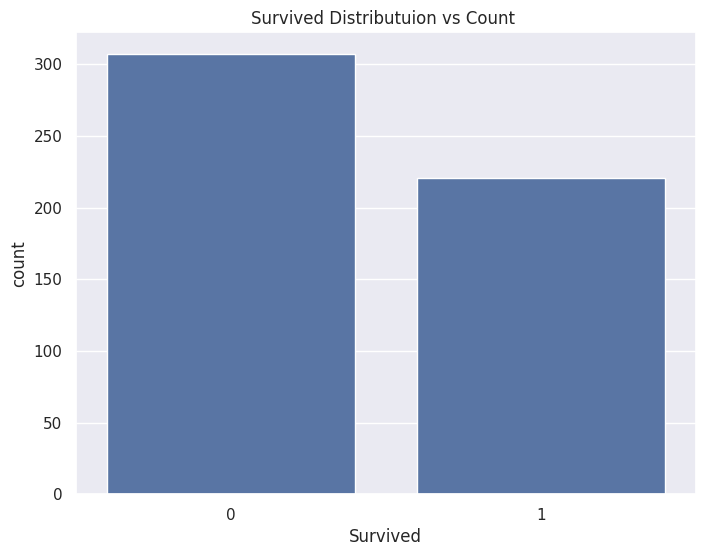

In [ ]:
# Survived Distributuion

plt.figure(figsize=(8,6))
sns.countplot(x="Survived",data=df)
plt.title("Survived Distributuion vs Count ")
plt.show()


In [ ]:
df

,Class,Sex,Age,Bed Cost(£),Hospital,Survived
0,0,1,22.0,7.2500,2,0
1,1,0,38.0,71.2833,0,1
2,0,0,26.0,7.9250,2,1
3,1,0,35.0,53.1000,2,1
4,0,1,35.0,8.0500,2,0
...,...,...,...,...,...,...
592,0,1,47.0,7.2500,2,0
595,0,1,36.0,24.1500,2,0
596,2,0,29.0,33.0000,2,1
597,0,1,49.0,0.0000,2,0


In [ ]:
# Initialize and fit StandardScaler to 'Age' and 'Bed Cost(£)' columns, then transform these columns.

scaler = StandardScaler()
df[["Age","Bed Cost(£)"]] = scaler.fit_transform(df[["Age","Bed Cost(£)"]])


In [ ]:
df

,Class,Sex,Age,Bed Cost(£),Hospital,Survived
0,0,1,-0.586482,-0.558355,2,0
1,1,0,0.569515,0.762357,0,1
2,0,0,-0.297483,-0.544433,2,1
3,1,0,0.352765,0.387319,2,1
4,0,1,0.352765,-0.541855,2,0
...,...,...,...,...,...,...
592,0,1,1.219763,-0.558355,2,0
595,0,1,0.425015,-0.209786,2,0
596,2,0,-0.080734,-0.027251,2,1
597,0,1,1.364263,-0.707889,2,0


## 3. Splitting Data into Training and Testing Sets

In [ ]:
# Separate features (X) and target variable (y)

X = df.drop("Survived", axis = 1)
y = df["Survived"]

In [ ]:
# Split the dataset to train and test set

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [ ]:
y_train.value_counts()

,count
Survived,
0,246
1,176


In [ ]:
X_train.shape

(422, 5)

In [ ]:
X_test.shape

(106, 5)

In [ ]:
y_train.shape

(422,)

In [ ]:
y_test.shape

(106,)

# 4. Balance class distribution

In [ ]:
# Initialize SMOTE for oversampling the minority class in the training data.
# random_state ensures consistent results across multiple runs.

SMOTE_m = SMOTE(random_state = 42)


In [ ]:
# Apply SMOTE to resample the minority class in the training data, ensuring balanced class distribution.

X_res, y_res = SMOTE_m.fit_resample(X_train,y_train)


In [ ]:
y_res.value_counts()

,count
Survived,
0,246
1,246


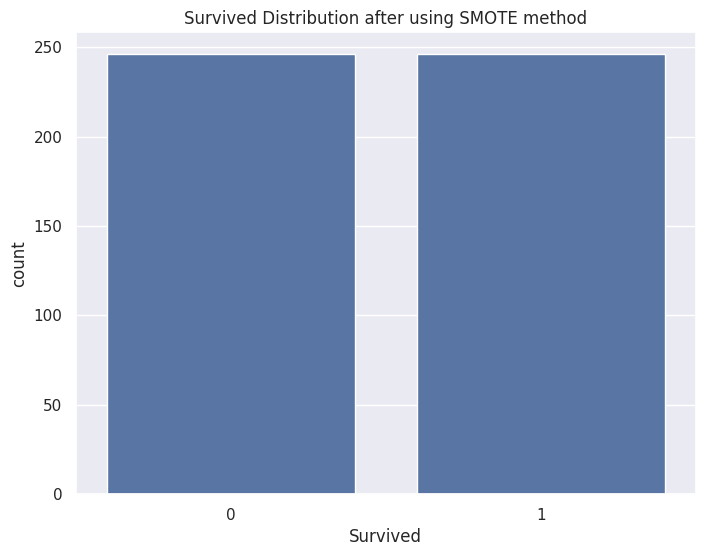

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming X_res and y_res are your features and target after SMOTE
# Create a DataFrame for plotting
smote_df = pd.DataFrame(X_res, columns=X.columns)
smote_df['Survived'] = y_res

# Create the countplot
plt.figure(figsize=(8, 6))
sns.countplot(x='Survived', data=smote_df)
plt.title('Survived Distribution after using SMOTE method')
plt.show()

# 5. Model Building and Evaluation

In [ ]:


# Logistic Regression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, logreg_pred))
print(classification_report(y_test, logreg_pred))
print(confusion_matrix(y_test, logreg_pred))


Logistic Regression Accuracy: 0.7735849056603774
              precision    recall  f1-score   support

           0       0.79      0.82      0.81        61
           1       0.74      0.71      0.73        45

    accuracy                           0.77       106
   macro avg       0.77      0.77      0.77       106
weighted avg       0.77      0.77      0.77       106

[[50 11]
 [13 32]]


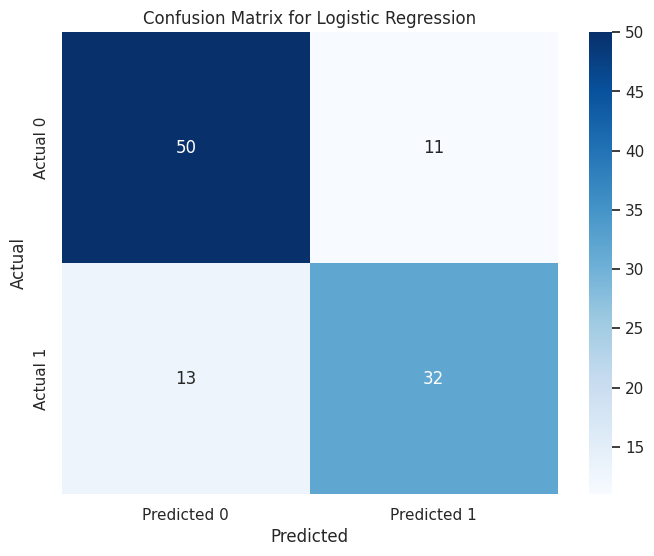

In [ ]:
# Logistic Regression Confusion Matrix
cm = confusion_matrix(y_test, logreg_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Decision Tree
dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)
dtree_pred = dtree.predict(X_test)

print("\nDecision Tree Accuracy:", accuracy_score(y_test, dtree_pred))
print(classification_report(y_test, dtree_pred))
print(confusion_matrix(y_test, dtree_pred))



Decision Tree Accuracy: 0.7358490566037735
              precision    recall  f1-score   support

           0       0.75      0.80      0.78        61
           1       0.71      0.64      0.67        45

    accuracy                           0.74       106
   macro avg       0.73      0.72      0.73       106
weighted avg       0.73      0.74      0.73       106

[[49 12]
 [16 29]]


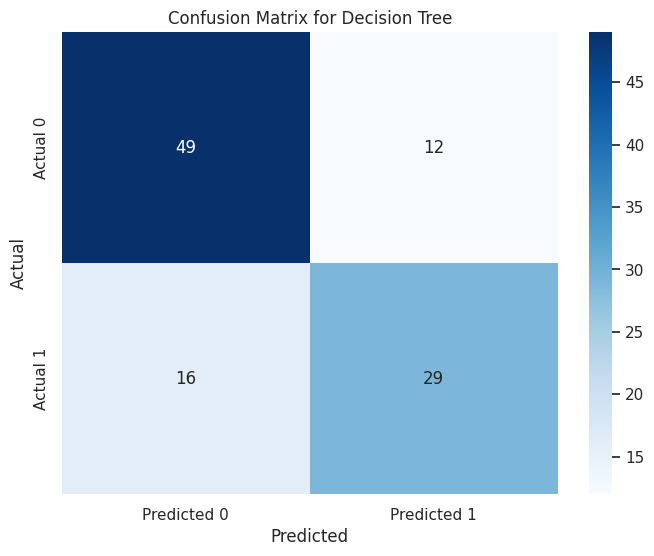

In [ ]:
# Decision Tree Confusion Matrix
cm_dtree = confusion_matrix(y_test, dtree_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dtree, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("\nRandom Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))



Random Forest Accuracy: 0.7735849056603774
              precision    recall  f1-score   support

           0       0.76      0.89      0.82        61
           1       0.80      0.62      0.70        45

    accuracy                           0.77       106
   macro avg       0.78      0.75      0.76       106
weighted avg       0.78      0.77      0.77       106

[[54  7]
 [17 28]]


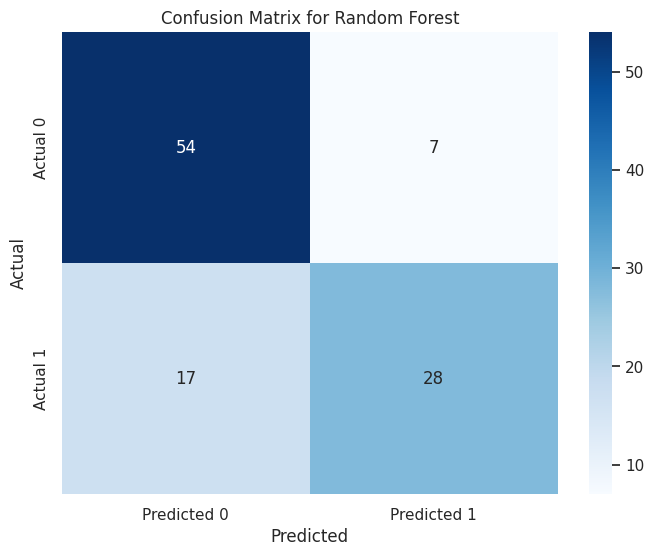

In [ ]:
# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Support Vector Machine (SVM)
svm = SVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

print("\nSVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))
print(confusion_matrix(y_test, svm_pred))



SVM Accuracy: 0.7641509433962265
              precision    recall  f1-score   support

           0       0.72      0.97      0.83        61
           1       0.92      0.49      0.64        45

    accuracy                           0.76       106
   macro avg       0.82      0.73      0.73       106
weighted avg       0.80      0.76      0.75       106

[[59  2]
 [23 22]]


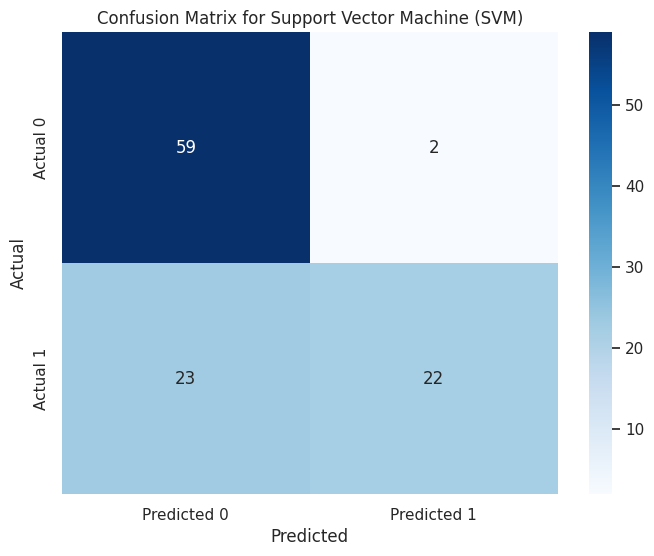

In [ ]:
# Support Vector Machine (SVM) Confusion Matrix
cm_svm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Support Vector Machine (SVM)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

print("\nKNN Accuracy:", accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))
print(confusion_matrix(y_test, knn_pred))



KNN Accuracy: 0.7547169811320755
              precision    recall  f1-score   support

           0       0.73      0.90      0.81        61
           1       0.81      0.56      0.66        45

    accuracy                           0.75       106
   macro avg       0.77      0.73      0.73       106
weighted avg       0.76      0.75      0.74       106

[[55  6]
 [20 25]]


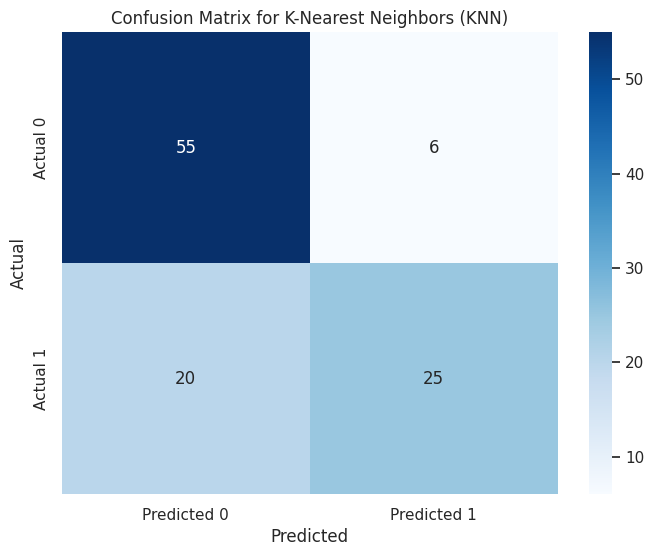

In [ ]:
# K-Nearest Neighbors (KNN) Confusion Matrix
cm_knn = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for K-Nearest Neighbors (KNN)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)
gnb_pred = gnb.predict(X_test)

print("\nGaussian Naive Bayes Accuracy:", accuracy_score(y_test, gnb_pred))
print(classification_report(y_test, gnb_pred))
print(confusion_matrix(y_test, gnb_pred))




Gaussian Naive Bayes Accuracy: 0.7452830188679245
              precision    recall  f1-score   support

           0       0.78      0.77      0.78        61
           1       0.70      0.71      0.70        45

    accuracy                           0.75       106
   macro avg       0.74      0.74      0.74       106
weighted avg       0.75      0.75      0.75       106

[[47 14]
 [13 32]]


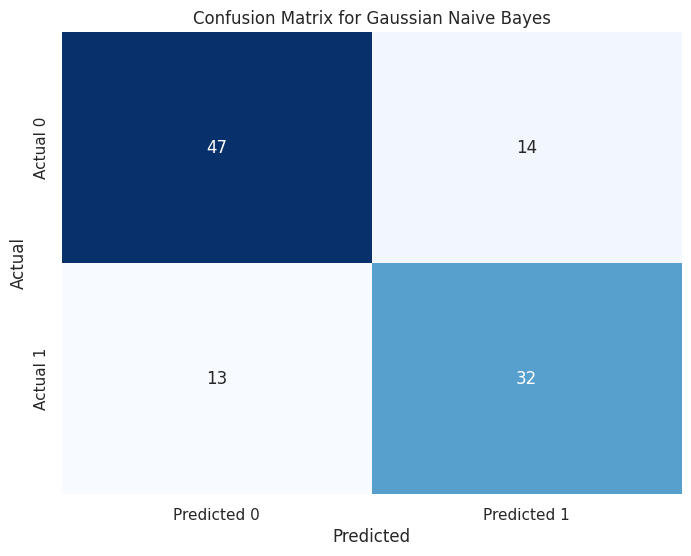

In [ ]:
# Gaussian Naive Bayes Confusion Matrix
cm_gnb = confusion_matrix(y_test, gnb_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_gnb, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'],cbar=False)
plt.title('Confusion Matrix for Gaussian Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 6. Model Comparison and Selection

In [ ]:
# Create a DataFrame to store the classification reports
model_names = ["Logistic Regression", "Decision Tree", "Random Forest", "SVM", "KNN", "GNB"]
models = [logreg, dtree, rf, svm, knn, gnb]
reports = {}
classification_metrics = pd.DataFrame(index=model_names, columns=['Precision', 'Recall', 'F1-score', 'Accuracy'])

for name, model in zip(model_names, models):
    pred = model.predict(X_test)
    report = classification_report(y_test, pred, output_dict=True)
    classification_metrics.loc[name, 'Precision'] = report['weighted avg']['precision']
    classification_metrics.loc[name, 'Recall'] = report['weighted avg']['recall']
    classification_metrics.loc[name, 'F1-score'] = report['weighted avg']['f1-score']
    classification_metrics.loc[name, 'Accuracy'] = report['accuracy']

# Display the table of classification reports
classification_metrics

,Precision,Recall,F1-score,Accuracy
Logistic Regression,0.772652,0.773585,0.772838,0.773585
Decision Tree,0.734093,0.735849,0.733899,0.735849
Random Forest,0.777305,0.773585,0.76801,0.773585
SVM,0.80321,0.764151,0.745578,0.764151
KNN,0.764374,0.754717,0.74475,0.754717
GNB,0.74611,0.745283,0.74563,0.745283


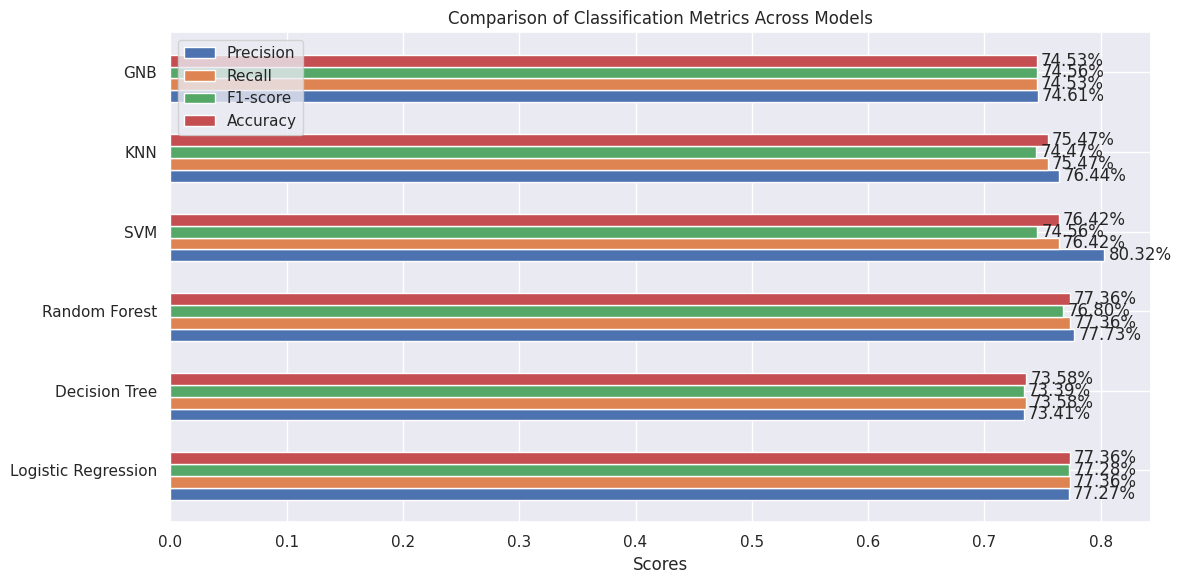

In [ ]:
# Store classification reports in a dictionary
model_names = ["Logistic Regression", "Decision Tree", "Random Forest", "SVM", "KNN", "GNB"]
models = [logreg, dtree, rf, svm, knn, gnb]
reports = {}

for name, model in zip(model_names, models):
    pred = model.predict(X_test)
    reports[name] = classification_report(y_test, pred, output_dict=True)

# Function to extract metrics from classification reports
def get_metrics(reports):
  precision = []
  recall = []
  f1 = []
  accuracy = []

  for model_name in model_names:
    report = reports[model_name]
    precision.append(report['weighted avg']['precision'])
    recall.append(report['weighted avg']['recall'])
    f1.append(report['weighted avg']['f1-score'])
    accuracy.append(report['accuracy'])

  return precision, recall, f1, accuracy

# Extract metrics using the function
precision, recall, f1, accuracy = get_metrics(reports)

# Create the horizontal bar chart for comparison of all models
metrics_to_plot = [precision, recall, f1, accuracy]
metric_labels = ['Precision', 'Recall', 'F1-score', 'Accuracy']

x = np.arange(len(model_names))  # the label locations
width = 0.15  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))
rects = []

for i, metric in enumerate(metrics_to_plot):
    rects.append(ax.barh(x + i * width, metric, width, label=metric_labels[i]))

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Scores')
ax.set_title('Comparison of Classification Metrics Across Models')
ax.set_yticks(x + width * 2, model_names) # Center y-ticks
ax.legend(loc='upper left') # Move legend to the left


# Attach a text label above each bar in *rects*, displaying its height.
def autolabel(rects):
    for rect in rects:
        width = rect.get_width()
        ax.annotate(f'{width:.2%}', # Display as percentage
                    xy=(width, rect.get_y() + rect.get_height() / 2),
                    xytext=(3, 0),
                    textcoords="offset points",
                    ha='left', va='center')


for rect in rects:
    autolabel(rect)

fig.tight_layout()
plt.show()